# Getting started with the synthetic capture generator

This notebook walks through the whole generator in six steps:

1. **Load a device profile** measured from a real transmitter
2. **Understand the two halves** — what is fixed per device, what varies per run
3. **Generate one run** and look at the waveform it produces
4. **Read the ground truth** — exactly what was injected
5. **Change how a parameter varies** — the part you will actually customise
6. **Write a dataset** to disk and read it back

Requirements beyond the generator itself: `matplotlib` for the plots.

## Setup

The generator lives in one module. Importing it loads the measured calibration data (the BB60C receiver response, the SRRC ripple curves) once.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

# The generator parses its own command line at import, so blank argv first.
sys.argv = ["notebook"]
sys.path.insert(0, ".")
sys.path.insert(0, "PA_modelling_with_GMP")

import synth_dataset as generator

print(f"sample rate       {generator.FS/1e6:.1f} MHz")
print(f"samples/symbol    {generator.SPS}")
print(f"burst             {generator.N_PRE} preamble + {generator.N_DATA} data "
      f"+ {generator.N_TAIL} tail symbols = {generator.BURST_LEN} samples")

sample rate       5.0 MHz
samples/symbol    5
burst             100 preamble + 1000 data + 200 tail symbols = 6500 samples


### Which devices are available?

Each entry in the fitted-tap store is one transmitter at one configuration. The configuration name is `<gain>_<band in MHz>`.

In [2]:
tap_store = json.loads(Path("data/isi_taps.json").read_text())
device_config_pairs = sorted(k for k in tap_store if not k.startswith("_"))

available_radios = sorted({pair.split("/")[0] for pair in device_config_pairs})
available_configs = sorted({pair.split("/")[1] for pair in device_config_pairs})

print(f"{len(available_radios)} transmitters, {len(available_configs)} configurations")
print(f"transmitters   {', '.join(available_radios[:6])} ...")
print(f"configurations {', '.join(available_configs)}")

22 transmitters, 6 configurations
transmitters   30BF779, 30BF795, 30BF796, 30BF7A4, 30BF7AB, 30BF7B6 ...
configurations 77_2400, 77_433, 77_915, 89_2400, 89_433, 89_915


## 1. Load a device profile

`profile_from_log` returns **two** dictionaries, and the split is the core idea
of the generator:

- **`device_profile`** — the centre value of every impairment for this
  transmitter. These are the numbers that make radio A different from radio B.
- **`variation_spec`** — how each of those numbers is redrawn on every run.
  These describe what changes when you re-record the *same* radio.

A parameter that belongs in the profile but not the variation spec is a
fingerprint. One that varies a lot run to run is not.

In [3]:
RADIO = "30BF779"
CONFIG = "89_433"          # gain 89, 433 MHz

device_profile, variation_spec = generator.profile_from_log(RADIO, CONFIG)

print(f"profile keys:   {len(device_profile)}")
print(f"varying params: {len(variation_spec)}")
print(f"carrier:        {device_profile['fc_hz']/1e6:.2f} MHz")
print(f"built from:     {device_profile['n_real_runs']} real recorded runs")

profile keys:   32
varying params: 17
carrier:        433.92 MHz
built from:     100 real recorded runs


`describe` prints the whole chain — every block, its fitted value, and how it varies. This is the same output as `--dry-run` on the command line.

In [4]:
generator.describe(device_profile, variation_spec)


30BF779 / 89_433   (100 real runs, fc 433.92 MHz)
  parameter                  value   variation
  ref_ppm                  -1.5753   AR(1) sd=0.00092363 phi=0.039
  clock_mismatch_ppm       -1.5655   derived from ref_ppm (shared reference)
  iq_amp_db              0.0043606   Gaussian sd=0.03664
  iq_phase_deg            0.036053   Gaussian sd=0.25262
  snr_db                    49.076   Gaussian sd=0.05849
  lo_leak_dbc              -65.531   mixture 0.24@-77.25+/-2.07, 0.76@-65.14+/-1.99
  cp0_samp                       0   Uniform [-0.5, 0.5]
  phi0_rad                       0   Uniform [0, 6.283]
  rx_dc_frac            7.5876e-06   held at the profile value
  pa_b_re                 -0.17587   held at the profile value
  pa_b_im                0.0004041   held at the profile value
  pn_level_db                    0   held at the profile value
  pn_radial_pct                  0   held at the profile value
  ripple                             common-mode FIR, 301 taps, 0.0299 dB r

### Reading the variation spec

Each entry names a distribution `kind`. The generator ships seven:

| kind | redrawn each run as |
| --- | --- |
| `fixed` | not redrawn — held at the profile value |
| `derived` | tied to another parameter |
| `uniform` | uniform over a measured range |
| `gauss` | Gaussian at the measured spread |
| `ar1` | Gaussian that *wanders*, so run 51 resembles run 50 |
| `mixture` | a Gaussian mixture, for genuinely multi-modal quantities |
| `scipy` | any `scipy.stats` distribution, by name |

In [5]:
for name in ["ref_ppm", "iq_phase_deg", "lo_leak_dbc", "cp0_samp"]:
    print(f"{name:16} {json.dumps(variation_spec[name])}")

ref_ppm          {"kind": "ar1", "sd": 0.0009236273558948021, "phi": 0.038629954112001305}
iq_phase_deg     {"kind": "gauss", "sd": 0.2526187007683525}
lo_leak_dbc      {"kind": "mixture", "w": [0.24072991044530645, 0.7592700895546934], "mu": [-77.24543406523998, -65.1409200022336], "sd": [2.0705441203284805, 1.9924222995224314], "lo": -82.57595701327827, "hi": -58.76586397447848}
cp0_samp         {"kind": "uniform", "lo": -0.5, "hi": 0.5}


Note `lo_leak_dbc`: the TX LO leakage is genuinely **bimodal** on most
radio/configurations, so a single Gaussian would put its peak in the empty
valley between the two lobes. The generator fits a mixture instead, and only
uses one where the evidence supports it.

## 2. Generate one run

`synth_run` builds one burst train. It takes the profile, the variation spec, a
random generator, and a `state` dict that carries memory for the wandering
(`ar1`) parameters across runs.

It returns three things: the transmitted waveform, the received waveform, and
**the values it actually drew** for this run.

In [6]:
random_generator = np.random.default_rng(seed=0)
ar1_memory = {}                 # carries run-to-run memory; empty on the first run
N_BURSTS = 8

transmitted, received, injected_values = generator.synth_run(
    device_profile, variation_spec, random_generator, ar1_memory, N_BURSTS)

print(f"transmitted  {transmitted.shape}  {transmitted.dtype}")
print(f"received     {received.shape}  {received.dtype}")
print(f"{N_BURSTS} bursts, spaced {generator.BURST_SPACING} samples apart")

transmitted  (6500,)  complex64
received     (52200,)  complex64
8 bursts, spaced 6525 samples apart


### What one burst looks like

The amplitude ramp at each end of the burst is **SRRC pulse shaping** - the
transmit filter running up and down over the burst edges. It is not an
impairment.

The **burst transient** is a separate, measured effect, and it is almost purely
a *phase* effect. The fitted coefficients for this device sit at -92.4, +87.6
and -92.5 degrees, i.e. essentially on the imaginary axis. Across the burst it
swings the phase by about 2 degrees while moving the amplitude by under half a
percent. The clean way to see it is to generate the same burst with the block
on and off, and take the ratio.

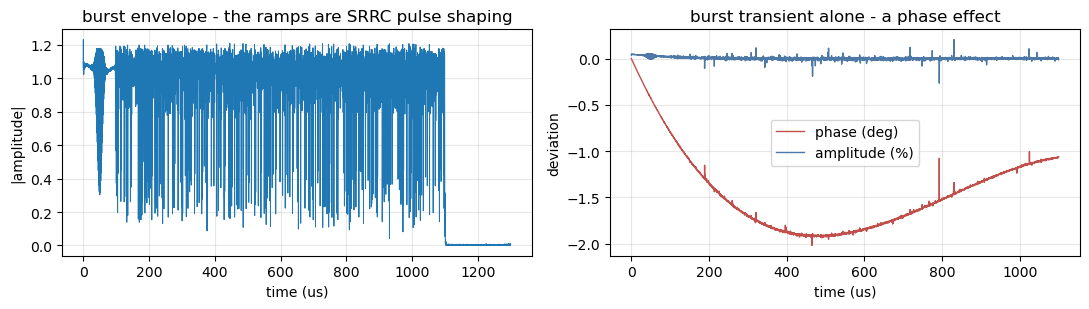

phase swing     2.02 deg
amplitude swing 0.47 %


In [7]:
import copy

first_burst = received[:generator.BURST_LEN]
time_us = np.arange(len(first_burst)) / generator.FS * 1e6

# Isolate the transient: same burst, block on vs off. Freezing every varying
# parameter means the ONLY difference between the two is the settling block.
frozen_spec = {name: {"kind": "fixed"} for name in variation_spec}

def burst_from(profile):
    return generator.synth_run(profile, frozen_spec, np.random.default_rng(0),
                               {}, 1)[1][:generator.BURST_LEN]

with_transient = burst_from(copy.deepcopy(device_profile))
without_transient = burst_from({**copy.deepcopy(device_profile),
                                "settling": [], "settling_shape": None})

safe_divisor = np.where(np.abs(without_transient) > 1e-12, without_transient, 1e-12)
transient_only = with_transient / safe_divisor
active = slice(0, (generator.N_PRE + generator.N_DATA) * generator.SPS)

transient_phase_deg = np.degrees(np.angle(transient_only[active]))
transient_amp_pct = (np.abs(transient_only[active]) - 1.0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(time_us, np.abs(first_burst), lw=0.7)
axes[0].set_title("burst envelope - the ramps are SRRC pulse shaping")
axes[0].set_xlabel("time (us)"); axes[0].set_ylabel("|amplitude|")
axes[0].grid(alpha=0.3)

axes[1].plot(time_us[active], transient_phase_deg, lw=1.0, color="#C1504D",
             label="phase (deg)")
axes[1].plot(time_us[active], transient_amp_pct, lw=1.0, color="#4E79A7",
             label="amplitude (%)")
axes[1].set_title("burst transient alone - a phase effect")
axes[1].set_xlabel("time (us)"); axes[1].set_ylabel("deviation")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"phase swing     {np.ptp(transient_phase_deg):.2f} deg")
print(f"amplitude swing {np.ptp(transient_amp_pct):.2f} %")

### The constellation

To see the constellation we undo the carrier offset. Because this is synthetic
data we know the offset **exactly** — it is in `injected_values` — so no
estimator is involved. That is the whole point of a generator with ground truth.

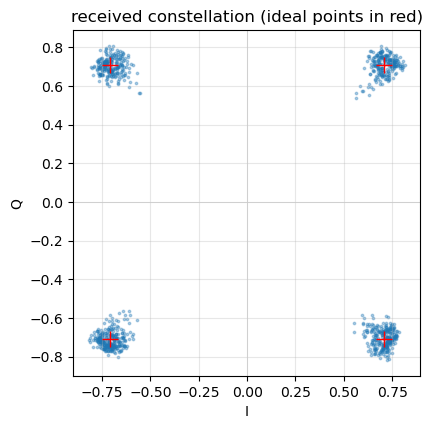

In [8]:
def symbols_at_decision_instants(waveform, profile, carrier_offset_ppm):
    """Matched-filter one burst and sample it at the symbol instants."""
    offset_hz = carrier_offset_ppm * 1e-6 * profile["fc_hz"]
    sample_index = np.arange(len(waveform))
    derotated = waveform * np.exp(-2j * np.pi * offset_hz / generator.FS * sample_index)

    filtered = scipy.signal.oaconvolve(derotated, generator.SRRC, mode="full")
    filtered = filtered[generator.MF_DELAY:generator.MF_DELAY + len(waveform)]

    data_start = generator.N_PRE * generator.SPS
    data_end = (generator.N_PRE + generator.N_DATA) * generator.SPS
    return filtered[data_start:data_end:generator.SPS]


received_symbols = symbols_at_decision_instants(
    first_burst, device_profile, injected_values["ref_ppm"])
transmitted_symbols = symbols_at_decision_instants(
    transmitted[:generator.BURST_LEN], device_profile, 0.0)

# Remove the constant phase by aligning against what we know was sent.
common_phase = np.angle(np.vdot(transmitted_symbols, received_symbols))
aligned = received_symbols * np.exp(-1j * common_phase)
aligned = aligned / np.sqrt(np.mean(np.abs(aligned) ** 2))

plt.figure(figsize=(4.4, 4.4))
plt.scatter(aligned.real, aligned.imag, s=3, alpha=0.35)
for point in [1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j]:
    plt.plot(point.real / np.sqrt(2), point.imag / np.sqrt(2), "r+", ms=12)
plt.axhline(0, color="0.8", lw=0.6); plt.axvline(0, color="0.8", lw=0.6)
plt.gca().set_aspect("equal"); plt.grid(alpha=0.3)
plt.title("received constellation (ideal points in red)")
plt.xlabel("I"); plt.ylabel("Q"); plt.tight_layout(); plt.show()

## 3. The ground truth

`injected_values` records what was drawn for this run. Every synthetic dataset
carries one of these per run, so an estimator can be scored against the truth
rather than against another estimator.

In [9]:
for name in ["ref_ppm", "clock_mismatch_ppm", "iq_amp_db", "iq_phase_deg",
             "lo_leak_dbc", "snr_db", "cp0_samp"]:
    print(f"{name:20} {injected_values[name]:+.6g}")

ref_ppm              -1.57519
clock_mismatch_ppm   -1.56497
iq_amp_db            +0.0176096
iq_phase_deg         +0.365468
lo_leak_dbc          -67.6622
snr_db               +49.1314
cp0_samp             -0.230213


### Watching a parameter vary across runs

Reusing the same `ar1_memory` dict across calls is what gives the wandering
parameters their run-to-run correlation. Here are 40 runs of the reference
oscillator and the LO leakage.

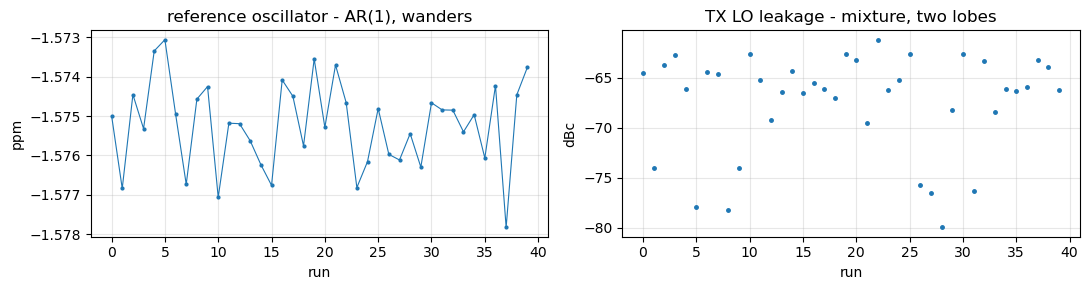

In [10]:
random_generator = np.random.default_rng(seed=1)
ar1_memory = {}
oscillator_ppm, leakage_dbc = [], []

for _ in range(40):
    _, _, drawn = generator.synth_run(
        device_profile, variation_spec, random_generator, ar1_memory, 1)
    oscillator_ppm.append(drawn["ref_ppm"])
    leakage_dbc.append(drawn["lo_leak_dbc"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
axes[0].plot(oscillator_ppm, ".-", lw=0.8, ms=4)
axes[0].set_title("reference oscillator - AR(1), wanders")
axes[0].set_xlabel("run"); axes[0].set_ylabel("ppm"); axes[0].grid(alpha=0.3)

axes[1].plot(leakage_dbc, ".", ms=5)
axes[1].set_title("TX LO leakage - mixture, two lobes")
axes[1].set_xlabel("run"); axes[1].set_ylabel("dBc"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Change how a parameter varies

This is the part you will customise. The variation spec is plain JSON, so you
can freeze a parameter, widen it, or swap in a different distribution entirely.

Three worked examples.

### (a) Freeze a parameter

Setting `kind` to `fixed` holds it at the profile value on every run — useful for isolating one impairment.

In [11]:
frozen_spec = json.loads(json.dumps(variation_spec))   # deep copy
frozen_spec["iq_phase_deg"] = {"kind": "fixed"}

random_generator = np.random.default_rng(seed=2)
memory = {}
frozen_values = [generator.synth_run(device_profile, frozen_spec,
                                     random_generator, memory, 1)[2]["iq_phase_deg"]
                 for _ in range(5)]
print("IQ phase, frozen: ", [f"{v:+.4f}" for v in frozen_values])

IQ phase, frozen:  ['+0.0361', '+0.0361', '+0.0361', '+0.0361', '+0.0361']


### (b) Widen a spread

Anything with a `sd` can be scaled directly — here to stress-test an estimator against 10x the real IQ spread.

In [12]:
widened_spec = json.loads(json.dumps(variation_spec))
widened_spec["iq_phase_deg"]["sd"] *= 10

random_generator = np.random.default_rng(seed=3)
memory = {}
widened_values = [generator.synth_run(device_profile, widened_spec,
                                      random_generator, memory, 1)[2]["iq_phase_deg"]
                  for _ in range(5)]
print(f"measured sd {variation_spec['iq_phase_deg']['sd']:.4f} deg")
print("IQ phase, 10x: ", [f"{v:+.4f}" for v in widened_values])

measured sd 0.2526 deg
IQ phase, 10x:  ['-5.0668', '+3.4149', '-5.1710', '-0.0964', '+2.3284']


### (c) Use any `scipy.stats` distribution

The `scipy` kind takes a distribution *name* plus its parameters. It stays
plain JSON, so the spec is still recorded in every dataset — which a Python
callback could not be.

110 scipy distributions available


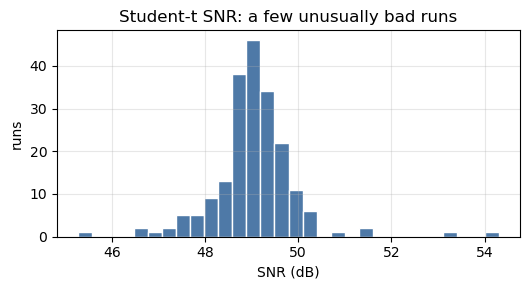

In [13]:
from scipy import stats

heavy_tailed_spec = json.loads(json.dumps(variation_spec))
heavy_tailed_spec["snr_db"] = {
    "kind": "scipy",
    "dist": "t",                                   # Student-t: occasional bad runs
    "params": {"df": 3, "loc": device_profile["snr_db"], "scale": 0.5},
}

random_generator = np.random.default_rng(seed=4)
memory = {}
snr_draws = [generator.synth_run(device_profile, heavy_tailed_spec,
                                 random_generator, memory, 1)[2]["snr_db"]
             for _ in range(200)]

print(f"{len(stats._continuous_distns._distn_names)} scipy distributions available")
plt.figure(figsize=(5.4, 3.0))
plt.hist(snr_draws, bins=30, color="#4E79A7", edgecolor="white")
plt.xlabel("SNR (dB)"); plt.ylabel("runs"); plt.grid(alpha=0.3)
plt.title("Student-t SNR: a few unusually bad runs")
plt.tight_layout(); plt.show()

## 5. Write a dataset

`generate` writes the real capture layout: one directory per run, SigMF data
and metadata, plus `profile.json` and `ground_truth.json` at the top.

In [14]:
output_root = Path("./notebook_out")

generate_kwargs = dict(n_runs=3, n_bursts=8, out=str(output_root), seed=7)
generator.generate(device_profile, variation_spec, verbose=False, **generate_kwargs)

for path in sorted(output_root.rglob("*"))[:12]:
    if path.is_file():
        print(f"{path.relative_to(output_root)}   ({path.stat().st_size/1024:.0f} KB)")

89_433\ground_truth.json   (2 KB)
89_433\profile.json   (28 KB)
89_433\run_001\valid\4qam_srrc_syn_tx_20260924T091257Z.sigmf-data   (51 KB)
89_433\run_001\valid\4qam_srrc_syn_tx_20260924T091257Z.sigmf-meta   (0 KB)
89_433\run_001\valid\capture_20260924T091257Z_combined.sigmf-data   (408 KB)
89_433\run_001\valid\capture_20260924T091257Z_combined.sigmf-meta   (1 KB)
89_433\run_002\valid\4qam_srrc_syn_tx_20260924T091257Z.sigmf-data   (51 KB)


## 6. Read it back

The captures are raw `complex64`. `ground_truth.json` gives the injected values
for every run, and `profile.json` records the exact profile and variation spec
that produced the dataset — so a result can always be traced to its inputs.

In [15]:
dataset_dir = output_root / CONFIG
ground_truth = json.loads((dataset_dir / "ground_truth.json").read_text())
stored = json.loads((dataset_dir / "profile.json").read_text())

print(f"{len(ground_truth)} runs of ground truth")
print(f"run 1 oscillator: {ground_truth[0]['ref_ppm']:+.6f} ppm")
print(f"leakage spec stored with the data: "
      f"{stored['variation']['lo_leak_dbc']['kind']}")

capture = next((dataset_dir / "run_001" / "valid").glob("capture_*.sigmf-data"))
samples = np.fromfile(capture, dtype=np.complex64)
print(f"\nread back {len(samples)} samples from {capture.name}")

3 runs of ground truth
run 1 oscillator: -1.575306 ppm
leakage spec stored with the data: mixture

read back 52200 samples from capture_20260924T091257Z_combined.sigmf-data


## Where to go next

- `python synth_dataset.py --help` — the command-line interface for bulk generation
- The module docstring in `synth_dataset.py` — the impairment order and why it matters
- `README.md` — the known limitations, which are worth reading before you
  trust any single block

**Cleanup:** the cell below deletes the dataset this notebook wrote.

In [16]:
import shutil
shutil.rmtree(output_root, ignore_errors=True)
print(f"removed {output_root}")

removed notebook_out
